# Datathon Assignment
Build a machine learning model to predict patient have heart disease or not.
I have used Explainable AI to find out what are the features are driving the overall decision making in heart disease prediction. 

### Data Description

 

* age: Age in years
* sex: 1 = male, 0 = female
* cp: Chest pain type
* trestbps: Resting blood pressure (in mm Hg on admission to the hospital)
* chol: serum cholesterol in mg/dl
* fbs: fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
* restecg: Resting electrocardiographic results
* thalach: Maximum heart rate achieved
* exang: Exercise induced angina (1 = yes; 0 = no)
* oldpeak: ST depression induced by exercise relative to rest
* slope: The slope of the peak exercise ST segment
* ca: Number of major vessels (0-4) colored by fluoroscopy
* thal: 0 = null, 1 = fixed defect found, 2 = blood flow is normal, 3 = reversible defect found
* target: 1 = Heart disease present, 0 = Heart disease not present

## Import Libraries

In [236]:
# package for data analysis
import pandas as pd

# package for numerical computations
import numpy as np

# libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# For Preprocessing, ML models and Evaluation
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score

#ignoring all warnings
import warnings
warnings.filterwarnings('ignore')

# import explinable AI package shap 
import shap

# load JS visualization code to notebook. Without this, the SHAP plots won't be displayed
shap.initjs()

## Load the data
Display the first 5 rows of the data after loading.

In [237]:
#import heart disease data using pandas
heart_data  = pd.read_csv("https://raw.githubusercontent.com/dphi-official/Datasets/master/Heart_Disease/Training_set_heart.csv" )
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,48,1,2,124,255,1,1,175,0,0.0,2,2,2,1
1,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
2,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
3,60,1,0,130,253,0,1,144,1,1.4,2,1,3,0
4,43,1,0,115,303,0,1,181,0,1.2,1,0,2,1


In [238]:
heart_data.shape # check shape of data

(212, 14)

In [239]:
# rename columns name for readabiity
columns_name = {'age':'Age','sex':'Sex','cp':'Cp','trestbps':'Trestbps','chol':'Chol','fbs':'Fbs','restecg':'Restecg','thalach':'Thalach','exang':'Exang','oldpeak':'Oldpeak','slope':'Slope','ca':'Ca','thal':'Thal','target':'Target'}
heart_data.rename(columns=columns_name, inplace=True)
heart_data.head()

,Age,Sex,Cp,Trestbps,Chol,Fbs,Restecg,Thalach,Exang,Oldpeak,Slope,Ca,Thal,Target
0,48,1,2,124,255,1,1,175,0,0.0,2,2,2,1
1,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
2,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
3,60,1,0,130,253,0,1,144,1,1.4,2,1,3,0
4,43,1,0,115,303,0,1,181,0,1.2,1,0,2,1


## Data Cleaning, Exploratory Data Analysis and Data Visualization

**Check Data Types and Missing Values**

In [240]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       212 non-null    int64  
 1   Sex       212 non-null    int64  
 2   Cp        212 non-null    int64  
 3   Trestbps  212 non-null    int64  
 4   Chol      212 non-null    int64  
 5   Fbs       212 non-null    int64  
 6   Restecg   212 non-null    int64  
 7   Thalach   212 non-null    int64  
 8   Exang     212 non-null    int64  
 9   Oldpeak   212 non-null    float64
 10  Slope     212 non-null    int64  
 11  Ca        212 non-null    int64  
 12  Thal      212 non-null    int64  
 13  Target    212 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 23.3 KB


In [241]:
heart_data.isnull().sum()

Age         0
Sex         0
Cp          0
Trestbps    0
Chol        0
Fbs         0
Restecg     0
Thalach     0
Exang       0
Oldpeak     0
Slope       0
Ca          0
Thal        0
Target      0
dtype: int64

Dataset contains only numeric data.

There are total 14 features with no missing value.

**Descriptive Statistics**

In [242]:
heart_data.describe()

,Age,Sex,Cp,Trestbps,Chol,Fbs,Restecg,Thalach,Exang,Oldpeak,Slope,Ca,Thal,Target
count,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000
mean,54.561321,0.688679,0.915094,132.127358,247.830189,0.165094,0.537736,148.995283,0.330189,1.008491,1.448113,0.783019,2.320755,0.542453
std,9.493376,0.464130,1.008193,17.440700,53.199877,0.372144,0.527437,23.332645,0.471394,1.141681,0.601850,1.066551,0.646495,0.499374
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,211.750000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,57.000000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,151.500000,0.000000,0.650000,2.000000,0.000000,2.000000,1.000000
75%,61.250000,1.000000,2.000000,140.000000,277.000000,0.000000,1.000000,165.250000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,192.000000,564.000000,1.000000,2.000000,202.000000,1.000000,5.600000,2.000000,4.000000,3.000000,1.000000


**Data Visualization**

In [243]:
# check unique values for target variable
heart_data['Target'].value_counts() 

1    115
0     97
Name: Target, dtype: int64

In [244]:
# Gets the percentage of unique values of target variable
heart_data['Target'].value_counts() / len(heart_data) * 100 

1    54.245283
0    45.754717
Name: Target, dtype: float64

In [245]:
heart_data.groupby('Target').mean()

,Age,Sex,Cp,Trestbps,Chol,Fbs,Restecg,Thalach,Exang,Oldpeak,Slope,Ca,Thal
Target,,,,,,,,,,,,,
0,56.639175,0.814433,0.391753,134.288660,252.855670,0.185567,0.422680,138.412371,0.577320,1.503093,1.206186,1.206186,2.525773
1,52.808696,0.582609,1.356522,130.304348,243.591304,0.147826,0.634783,157.921739,0.121739,0.591304,1.652174,0.426087,2.147826


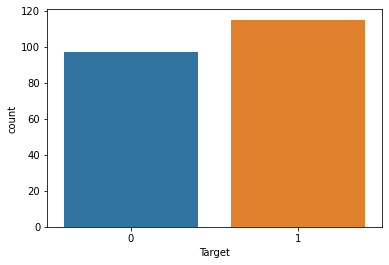

In [246]:
sns.countplot(heart_data['Target'])
plt.show()

We can observe that approx 115 person having heart disease and approx 95 person have no disease which shows that data is balanced.

**Correlation Matrix**

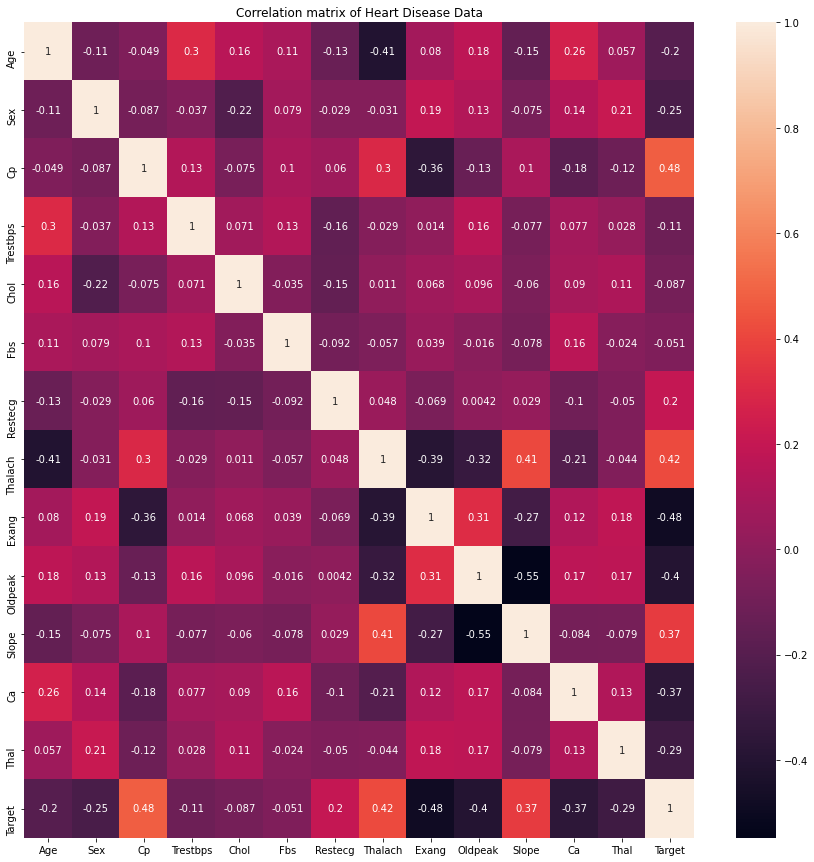

In [247]:
fig, ax = plt.subplots(figsize=(15,15))
sns.heatmap(heart_data.corr(), annot=True,ax=ax)
plt.title('Correlation matrix of Heart Disease Data')
plt.show()

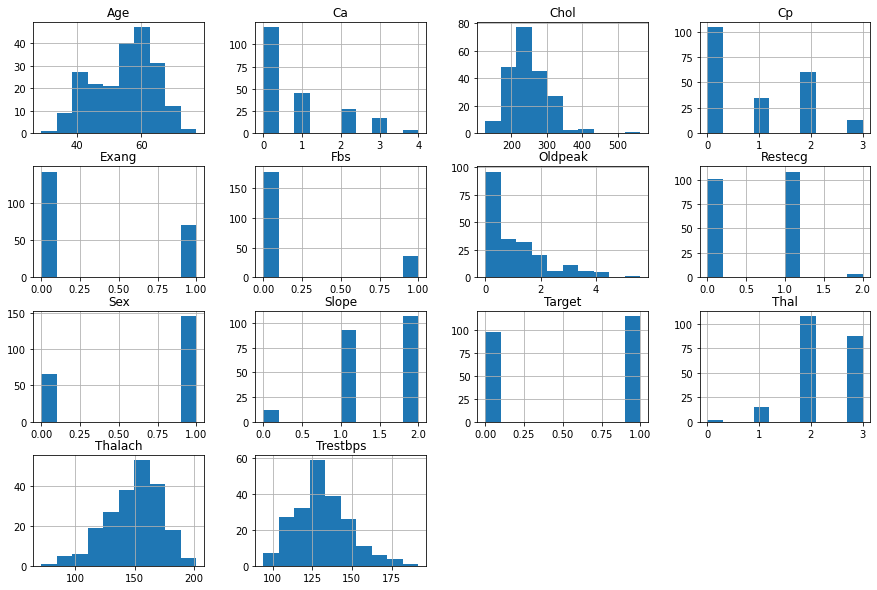

In [248]:
# plot the histograms of each variable
heart_data.hist(figsize=(15, 10))
plt.show()

**Observations**

Categorial Features: Ca, Cp, Exang, Fbs, Restecg, Sex, Slope, Target, Thal

Continuous Features: Age, Chol, Oldpeak, Thalach, Trestbps

**Check target variable distribution for Categorial features**

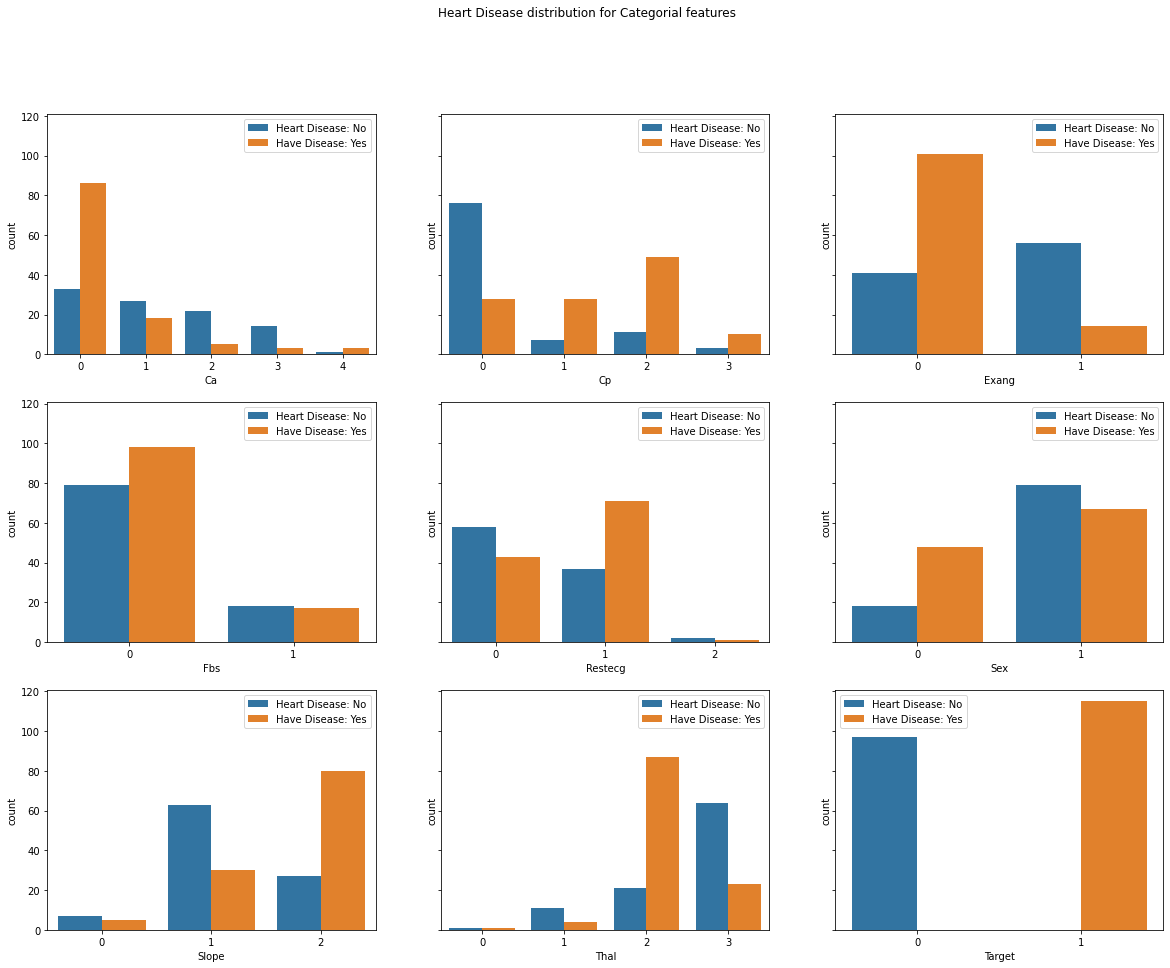

In [249]:
fig, ax = plt.subplots(3, 3, figsize=(20,15), sharey=True)
fig.suptitle('Heart Disease distribution for Categorial features')
features_categorial = ['Ca', 'Cp', 'Exang', 'Fbs', 'Restecg', 'Sex', 'Slope', 'Thal', 'Target']
for column, ax in enumerate(ax.flat):
    sns.countplot(x=features_categorial[column], hue='Target', data=heart_data, ax=ax) 
    ax.legend(["Heart Disease: No", "Have Disease: Yes"])

**Observations**

* Ca: People with value 0 for Number of major vessels (0-4) colored by flourosopy have higher risk of heart disease.
* Cp: People with value 0, 1, 2 for Chest Pain Type have higher risk heart disease than the Cp value 3.
* Exang: People with No Exercise induced angina have high risk of heart disease than the people who have exercice induced angina
* Fbs: People with higher value for fasting blood sugar have heart disease.
* Restecg: People with value 0 or 1 for resting electrocardiographic results have heart disease.
* Sex: Male have high risk of heart disease than the female.
* Slope: People with value 2 for Slope have higer risk of heart disease than people with value 0 or 1.
* Thal: People with value 2 for thalium stress result have higher risk of heart disease.

**Check target variable distribution for Continuous features**

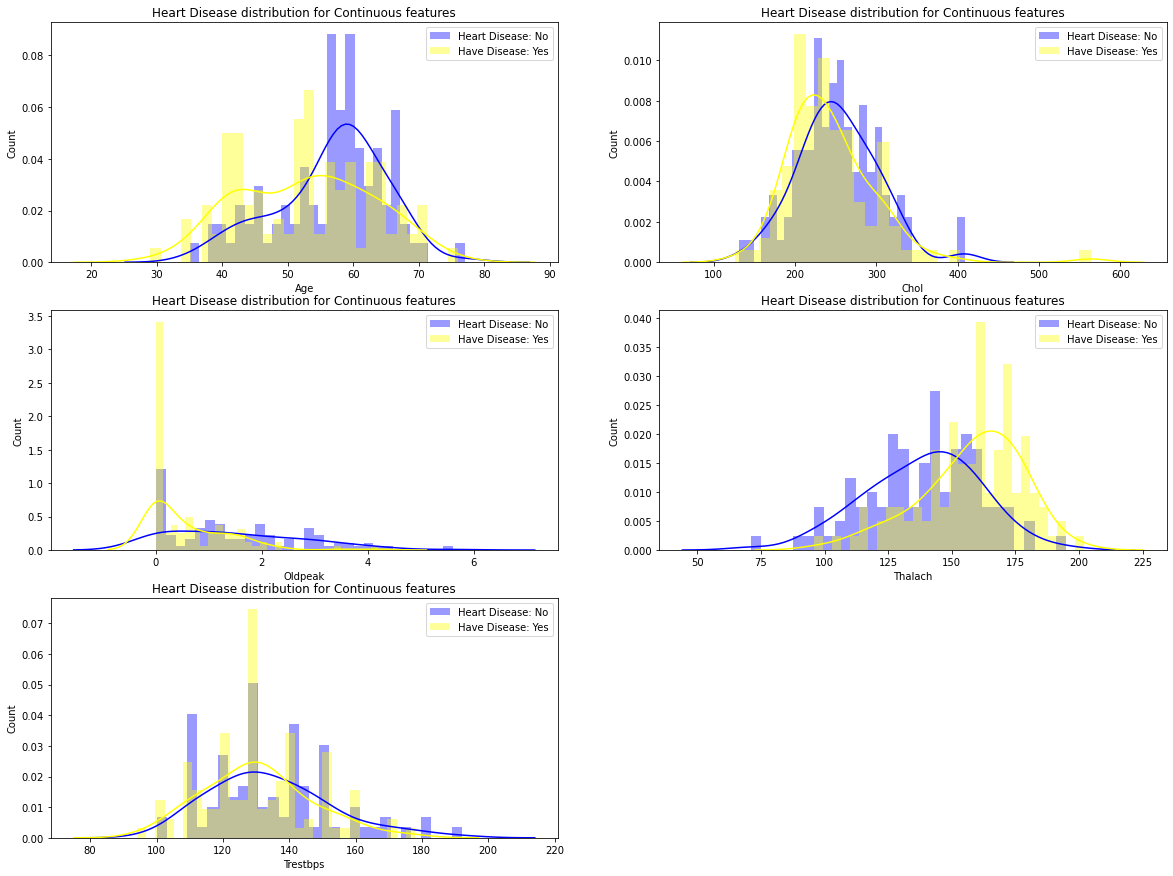

In [250]:
plt.figure(figsize=(20,15))
features_continuous = ['Age', 'Chol', 'Oldpeak', 'Thalach', 'Trestbps']

heart_data_with_disease = heart_data[heart_data['Target'] == 1]
heart_data_without_disease = heart_data[heart_data['Target'] == 0]

for x, column in enumerate(features_continuous, 1):
    plt.subplot(3, 2, x)
    sns.distplot(heart_data_without_disease[column], bins=30, color="blue", label="Heart Disease: No") 
    sns.distplot(heart_data_with_disease[column], bins=30, color="yellow", label="Have Disease: Yes") 
    plt.title('Heart Disease distribution for Continuous features')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend()
 

**Observations**

* Age: People within age range 40 to 70 have higher risk of heart disease.
* Chol: People with value above 200 for serum cholesterol have higher risk of heart disease.
* Oldpeak: People with value o to 2 for ST depression induced by exercise relative to rest have higher risk than the people with value above 2.
* Thalach: People with value range between 145 to 165 for thalach have higher risk of heart disease. 
* Trestbps : People with vaue 120 to 140 for resting blood pressure have higher risk for heart disease.

## Separate the Input and Target Features of the data

In [251]:
# Separating the input and output variables
X = heart_data.drop('Target',axis = 1) # input variable
y = heart_data['Target'] # output variable

In [252]:
X.head()

,Age,Sex,Cp,Trestbps,Chol,Fbs,Restecg,Thalach,Exang,Oldpeak,Slope,Ca,Thal
0,48,1,2,124,255,1,1,175,0,0.0,2,2,2
1,68,0,2,120,211,0,0,115,0,1.5,1,0,2
2,46,1,0,120,249,0,0,144,0,0.8,2,0,3
3,60,1,0,130,253,0,1,144,1,1.4,2,1,3
4,43,1,0,115,303,0,1,181,0,1.2,1,0,2


## Split the data into Train and Test Sets
Spliting the train to test with ratio 80:20 and the random_state should be 0.


In [253]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state = 0)

In [254]:
print(X_train.shape, X_test.shape)
X_train.head()

(169, 13) (43, 13)


,Age,Sex,Cp,Trestbps,Chol,Fbs,Restecg,Thalach,Exang,Oldpeak,Slope,Ca,Thal
16,58,1,0,150,270,0,0,111,1,0.8,2,0,3
135,50,0,0,110,254,0,0,159,0,0.0,2,0,2
122,52,1,0,112,230,0,1,160,0,0.0,2,1,2
22,70,1,2,160,269,0,1,112,1,2.9,1,1,3
80,54,0,2,110,214,0,1,158,0,1.6,1,0,2


## Data scaling

**Scaling train data**

In [255]:
# Using min max scaler
norm = MinMaxScaler()
columns = X_train.columns
X_train = norm.fit_transform(X_train)
X_train = pd.DataFrame(X_train, columns = columns)
X_train.head()

,Age,Sex,Cp,Trestbps,Chol,Fbs,Restecg,Thalach,Exang,Oldpeak,Slope,Ca,Thal
0,0.604167,1.0,0.000000,0.571429,0.321016,0.0,0.0,0.305344,1.0,0.142857,1.0,0.00,1.000000
1,0.437500,0.0,0.000000,0.163265,0.284065,0.0,0.0,0.671756,0.0,0.000000,1.0,0.00,0.666667
2,0.479167,1.0,0.000000,0.183673,0.228637,0.0,0.5,0.679389,0.0,0.000000,1.0,0.25,0.666667
3,0.854167,1.0,0.666667,0.673469,0.318707,0.0,0.5,0.312977,1.0,0.517857,0.5,0.25,1.000000
4,0.520833,0.0,0.666667,0.163265,0.191686,0.0,0.5,0.664122,0.0,0.285714,0.5,0.00,0.666667


**Scaling test data**

In [256]:
# Using min max scaler
norm = MinMaxScaler()
columns = X_test.columns
X_test = norm.fit_transform(X_test)
X_test = pd.DataFrame(X_test, columns = columns)
X_test.head()

,Age,Sex,Cp,Trestbps,Chol,Fbs,Restecg,Thalach,Exang,Oldpeak,Slope,Ca,Thal
0,0.648649,1.0,0.666667,0.441176,0.372807,1.0,0.0,0.689655,0.0,0.000000,1.0,0.0,0.666667
1,0.513514,0.0,0.666667,0.264706,0.394737,0.0,0.0,0.114943,0.0,0.000000,1.0,0.0,0.000000
2,0.567568,0.0,0.333333,0.323529,0.947368,0.0,0.5,0.701149,0.0,0.272727,1.0,0.0,0.666667
3,0.189189,1.0,0.333333,0.000000,0.478070,0.0,0.5,0.551724,0.0,0.000000,1.0,0.0,0.666667
4,0.810811,1.0,1.000000,0.882353,0.442982,0.0,0.0,0.574713,0.0,0.136364,0.5,0.0,1.000000


## Build a Logistic Regression Model on train set

In [257]:
#Building Logistic Regression model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

LogisticRegression()

In [258]:
# making prediction on test data
predictions = lr_model.predict(X_test)

## Evaluate the model using F1 Score

In [259]:
# F1 score
print('F1 Score: ',f1_score(y_test, predictions))
print('F1 Score %: ', round(f1_score(y_test, predictions),4)*100,'%')

F1 Score:  0.8571428571428572
F1 Score %:  85.71 %


### Load Test Data for prediction

In [260]:
test_data = pd.read_csv('https://raw.githubusercontent.com/dphi-official/Datasets/master/Heart_Disease/Testing_set_heart.csv')
print(test_data.shape)
test_data.head()

(91, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,46,0,0,138,243,0,0,152,1,0.0,1,0,2
1,45,0,0,138,236,0,0,152,1,0.2,1,0,2
2,59,1,3,160,273,0,0,125,0,0.0,2,0,2
3,44,0,2,108,141,0,1,175,0,0.6,1,0,2
4,47,1,2,108,243,0,1,152,0,0.0,2,0,2


In [261]:
# check column names and datatype
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       91 non-null     int64  
 1   sex       91 non-null     int64  
 2   cp        91 non-null     int64  
 3   trestbps  91 non-null     int64  
 4   chol      91 non-null     int64  
 5   fbs       91 non-null     int64  
 6   restecg   91 non-null     int64  
 7   thalach   91 non-null     int64  
 8   exang     91 non-null     int64  
 9   oldpeak   91 non-null     float64
 10  slope     91 non-null     int64  
 11  ca        91 non-null     int64  
 12  thal      91 non-null     int64  
dtypes: float64(1), int64(12)
memory usage: 9.4 KB


In [262]:
# rename columns name for readabiity
columns_name = {'age':'Age','sex':'Sex','cp':'Cp','trestbps':'Trestbps','chol':'Chol','fbs':'Fbs','restecg':'Restecg','thalach':'Thalach','exang':'Exang','oldpeak':'Oldpeak','slope':'Slope','ca':'Ca','thal':'Thal','target':'Target'}
test_data.rename(columns=columns_name, inplace=True)
test_data.head()

,Age,Sex,Cp,Trestbps,Chol,Fbs,Restecg,Thalach,Exang,Oldpeak,Slope,Ca,Thal
0,46,0,0,138,243,0,0,152,1,0.0,1,0,2
1,45,0,0,138,236,0,0,152,1,0.2,1,0,2
2,59,1,3,160,273,0,0,125,0,0.0,2,0,2
3,44,0,2,108,141,0,1,175,0,0.6,1,0,2
4,47,1,2,108,243,0,1,152,0,0.0,2,0,2


**Check null values in test data**

In [263]:
test_data.isnull().sum() 

Age         0
Sex         0
Cp          0
Trestbps    0
Chol        0
Fbs         0
Restecg     0
Thalach     0
Exang       0
Oldpeak     0
Slope       0
Ca          0
Thal        0
dtype: int64

**Scaling test data**

In [264]:
# Using min max scaler
norm1 = MinMaxScaler()
columns = test_data.columns
test_data = norm1.fit_transform(test_data)
test_data = pd.DataFrame(test_data, columns = columns)
test_data.head()

,Age,Sex,Cp,Trestbps,Chol,Fbs,Restecg,Thalach,Exang,Oldpeak,Slope,Ca,Thal
0,0.300,0.0,0.000000,0.415094,0.369565,0.0,0.0,0.627451,1.0,0.000000,0.5,0.0,0.5
1,0.275,0.0,0.000000,0.415094,0.344203,0.0,0.0,0.627451,1.0,0.032258,0.5,0.0,0.5
2,0.625,1.0,1.000000,0.622642,0.478261,0.0,0.0,0.362745,0.0,0.000000,1.0,0.0,0.5
3,0.250,0.0,0.666667,0.132075,0.000000,0.0,0.5,0.852941,0.0,0.096774,0.5,0.0,0.5
4,0.325,1.0,0.666667,0.132075,0.369565,0.0,0.5,0.627451,0.0,0.000000,1.0,0.0,0.5


**Model Prediction on test data**

In [265]:
# Using logistic regression
predictions_lr = lr_model.predict(test_data)
result = pd.DataFrame(predictions_lr)
result.index = test_data.index
result.columns = ["prediction"]
result.to_csv("lr_prediction_results.csv", index = False)

##  Derive SHAP Values for the logistic regression model.

In [266]:
# creating an explainer for our model
explainer = shap.LinearExplainer(lr_model, X_train)

# finding out the shap values using the explainer
shap_values = explainer.shap_values(X_test)

# Expected/Base/Reference value = the value that would be predicted if we didn’t know any features of the current output”
print('Expected Value:', explainer.expected_value)

# displaying the first 5 rows of the shap values table
df_shap_values = pd.DataFrame(shap_values, columns=X_test.columns)
df_shap_values.head()

Expected Value: 0.25433008662702017


,Age,Sex,Cp,Trestbps,Chol,Fbs,Restecg,Thalach,Exang,Oldpeak,Slope,Ca,Thal
0,-0.038384,-0.236615,0.736026,-0.054952,-0.004895,0.068850,-0.311365,0.120260,0.500726,0.157342,0.272681,0.203602,0.153386
1,0.002734,0.526659,0.736026,0.069842,-0.006032,-0.006809,-0.311365,-0.682771,0.500726,0.157342,0.272681,0.203602,1.289579
2,-0.013713,0.526659,0.101521,0.028244,-0.034701,-0.006809,0.190837,0.136320,0.500726,-0.179690,0.272681,0.203602,0.153386
3,0.101419,-0.236615,0.101521,0.257032,-0.010355,-0.006809,0.190837,-0.072468,0.500726,0.157342,0.272681,0.203602,0.153386
4,-0.087727,-0.236615,1.370531,-0.366935,-0.008535,-0.006809,-0.311365,-0.040346,0.500726,-0.011174,-0.307491,0.203602,-0.414710


In [267]:
df_shap_values.describe()

,Age,Sex,Cp,Trestbps,Chol,Fbs,Restecg,Thalach,Exang,Oldpeak,Slope,Ca,Thal
count,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
mean,-0.024041,-0.005858,0.190056,-0.031976,-0.011927,0.012545,-0.077783,-0.200206,0.021235,-0.201898,-0.078121,-0.135617,0.008059
std,0.065571,0.354694,0.765692,0.172165,0.011469,0.033402,0.276132,0.333408,0.698273,0.352905,0.382744,0.414055,0.448572
min,-0.145293,-0.236615,-0.532984,-0.450131,-0.037431,-0.006809,-0.311365,-0.843377,-0.971997,-1.078441,-0.887662,-1.011932,-0.414710
25%,-0.075391,-0.236615,-0.532984,-0.138147,-0.020708,-0.006809,-0.311365,-0.457922,-0.971997,-0.362249,-0.307491,-0.404165,-0.414710
50%,-0.038384,-0.236615,0.101521,-0.054952,-0.009673,-0.006809,-0.311365,-0.120649,0.500726,-0.123518,-0.307491,0.203602,0.153386
75%,0.010958,0.526659,0.736026,0.059442,-0.004781,0.031020,0.190837,0.031926,0.500726,0.101170,0.272681,0.203602,0.153386
max,0.158985,0.526659,1.370531,0.257032,0.014445,0.068850,0.693039,0.553896,0.500726,0.157342,0.272681,0.203602,1.289579


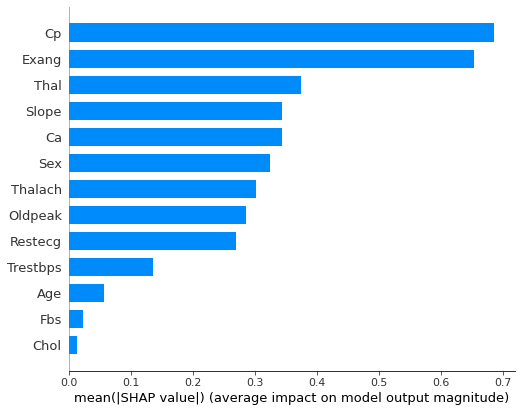

In [268]:
# generate bar plot 
shap.summary_plot(shap_values, X_test, plot_type='bar')

## Inferences from the generated plot.

From the above bar chart, we can observe that Cp, Exang and Thal Features are the top most important features while determining the heart disease. 

On the other hand, Chol and Fbs are the least important features while determining the heart disease.

## SHAP force plot for the first row of test data.

In [269]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])

## Inferences from the generated plot.

Based on the above plot, we can observe that Chest pain type (cp), and Exercise induced angina (exang) are positively related to heart disease prediction.

## SHAP force plot for all the rows of the data

In [270]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[:], X_test.iloc[:])

## Inferences from the generated plot.

The above plot all together shows the predictions and other factors impact on heart disease prediction for complete dataset.

## SHAP summary plot using all the features in the data

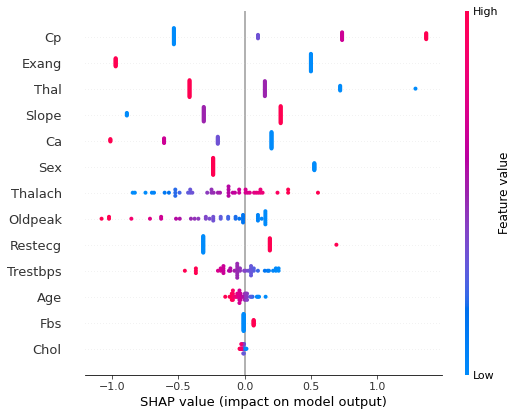

In [271]:
shap.initjs()
shap.summary_plot(shap_values, X_test)

## Inferences from the generated plot.

The above summary plot shows that cp has high and positive impact on heart disease prediction whereby exang and thal are negatively correlated with target variable.

## Dependence plot to see the effect of ‘chol’ across the whole dataset.

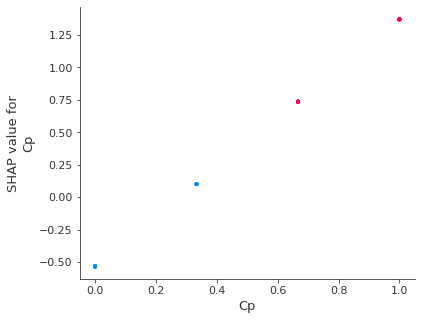

In [272]:
shap.initjs()
shap.dependence_plot(ind='Cp', interaction_index='Cp',
                     shap_values=shap_values, 
                     features=X_test)

## Inferences from the generated plot.

The above plot shows the positive linear relationship between serum cholesterol (chol) and target variable.

## Visualizing other dependence plot

**PDP of Thalach affecting model prediction**

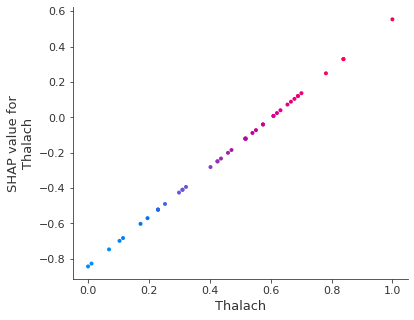

In [273]:
shap.initjs()
shap.dependence_plot(ind='Thalach', interaction_index='Thalach', 
                     shap_values=shap_values, features=X_test,display_features=X_test)

**PDP of Thal affecting model prediction**

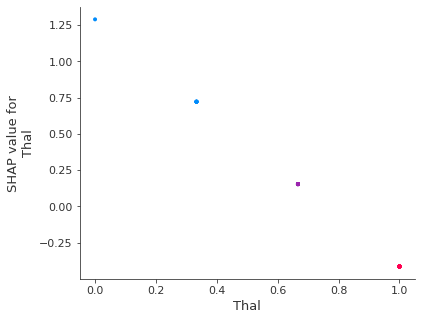

In [274]:
shap.initjs()
shap.dependence_plot(ind='Thal', interaction_index='Thal', 
                     shap_values=shap_values, features=X_test,display_features=X_test)

**PDP of Slope affecting model prediction**

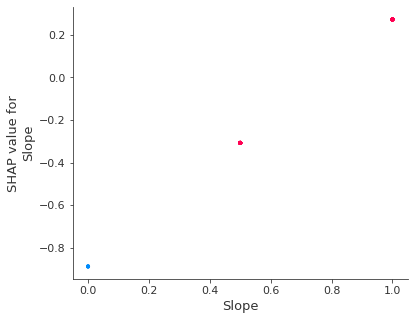

In [275]:
shap.initjs()
shap.dependence_plot(ind='Slope', interaction_index='Slope', 
                     shap_values=shap_values, features=X_test,display_features=X_test)

**Two-way PDP showing interactions between features ‘Chol’ and ‘Fbs’**

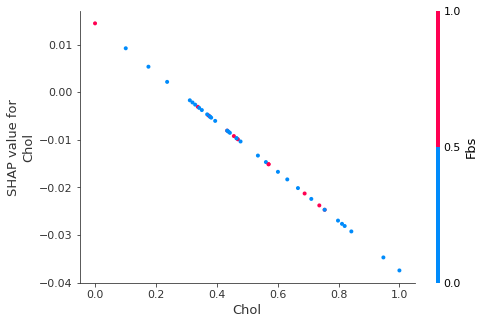

In [276]:
shap.initjs()
shap.dependence_plot(ind='Chol', interaction_index='Fbs', 
                     shap_values=shap_values, features=X_test)